In [2]:
import os
import shutil
import joblib

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder,StandardScaler, MinMaxScaler, RobustScaler

from sklearn.metrics import classification_report,accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc, f1_score, precision_score, recall_score

from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, cross_val_predict, cross_validate, train_test_split

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB,BernoulliNB,CategoricalNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import LatentDirichletAllocation as LDA
import h2o
from h2o.automl import H2OAutoML
from ydata_profiling import ProfileReport
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import optuna
from optuna.integration import OptunaSearchCV
from optuna.distributions import FloatDistribution

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv("C:\hassan\cess\semester 8\ML\project\Stroke-Prediction-ML\data\healthcare-dataset-stroke-data (2).csv")

df.drop('id', axis=1, inplace=True)
df.head()

<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
C:\Users\hassa\AppData\Local\Temp\ipykernel_19836\2116104957.py:10: SyntaxWarning: invalid escape sequence '\h'
  df = pd.read_csv("C:\hassan\cess\semester 8\ML\project\Stroke-Prediction-ML\data\healthcare-dataset-stroke-data (2).csv")


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

df_clean = df.copy()


knn_features = df_clean[['age', 'avg_glucose_level', 'bmi']].copy()

knn_features['bmi'] = knn_features['bmi'].astype(float)

scaler = StandardScaler()
knn_scaled = scaler.fit_transform(knn_features)

imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(knn_scaled)

knn_inverse = scaler.inverse_transform(knn_imputed)

df_clean['bmi'] = knn_inverse[:, 2]

print(f"Missing BMI values after KNN imputation: {df_clean['bmi'].isnull().sum()}")


Missing BMI values after KNN imputation: 0


In [4]:
# Function to remove outliers using IQR, keeping stroke=1 rows
def remove_outliers(df_clean, col):
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter only rows that are within bounds OR have stroke == 1
    return df_clean[
        (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound) | (df_clean['stroke'] == 1)
    ]
numerical_cols = ['age', 'avg_glucose_level', 'bmi']



# Remove outliers for numerical features
for col in numerical_cols:
    df_clean = remove_outliers(df_clean, col)

In [5]:
from sklearn.preprocessing import LabelEncoder

df_oh = df_clean.copy()

le = LabelEncoder()
df_oh['ever_married'] = le.fit_transform(df_oh['ever_married'])
df_oh['Residence_type'] = le.fit_transform(df_oh['Residence_type'])

# One-hot encoding
df_oh = pd.get_dummies(df_oh, columns=['gender', 'work_type', 'smoking_status'] , dtype=int)
# Verify
print(df_oh.columns)
df_oh.head()

Index(['age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Female',
       'gender_Male', 'gender_Other', 'work_type_Govt_job',
       'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='object')


,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,1,228.69,36.60,1,0,1,0,0,0,1,0,0,0,1,0,0
1,61.0,0,0,1,0,202.21,31.14,1,1,0,0,0,0,0,1,0,0,0,1,0
2,80.0,0,1,1,0,105.92,32.50,1,0,1,0,0,0,1,0,0,0,0,1,0
3,49.0,0,0,1,1,171.23,34.40,1,1,0,0,0,0,1,0,0,0,0,0,1
4,79.0,1,0,1,0,174.12,24.00,1,1,0,0,0,0,0,1,0,0,0,1,0


In [7]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_oh.drop('stroke', axis=1)
y = df_oh['stroke']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765 * 85% ≈ 15%

# Show the size of each set
print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))


Train set: 3133 samples
Validation set: 672 samples
Test set: 672 samples

Class distribution in training set:
stroke
0    0.944143
1    0.055857
Name: proportion, dtype: float64


=== Naïve Bayes Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.42      0.59       635
           1       0.09      0.97      0.16        37

    accuracy                           0.45       672
   macro avg       0.54      0.70      0.38       672
weighted avg       0.95      0.45      0.56       672



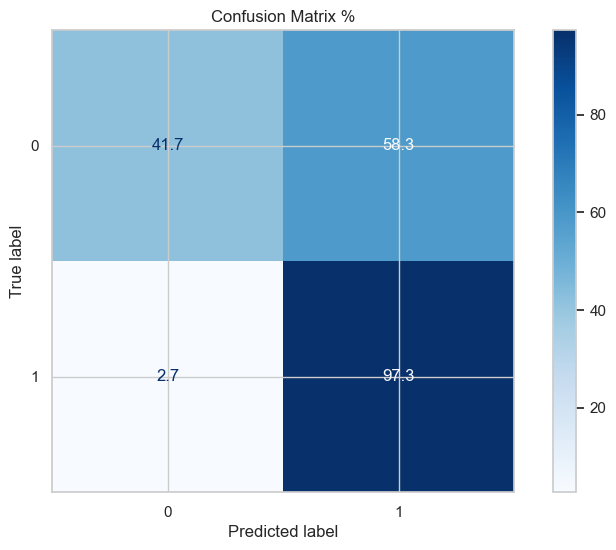

In [8]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train the model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_nb = nb_model.predict(X_val)

# Evaluate
print("=== Naïve Bayes Classification Report ===")
print(classification_report(y_val, y_val_pred_nb))

# Confusion Matrix in percentage
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
cm_nb_percentage = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis] * 100

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb_percentage,
                                display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues', values_format='.1f')
plt.title("Confusion Matrix %")
plt.show()

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_val)


In [10]:
y_pred_nb = nb_model.predict(X_val)

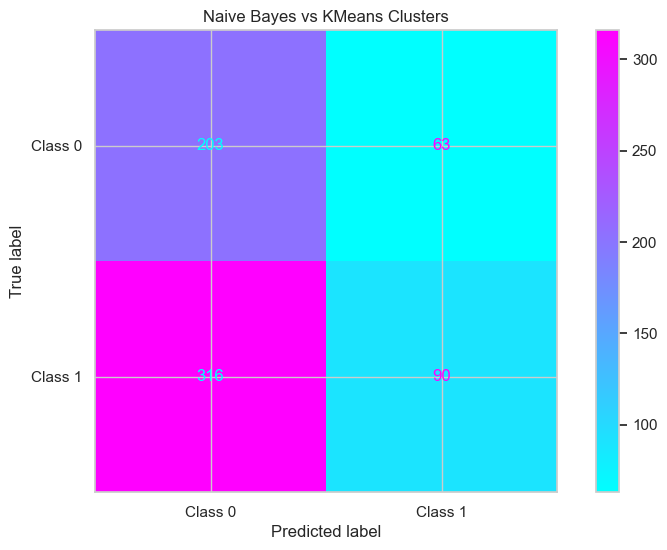

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Example: Naive Bayes vs KMeans
cm = confusion_matrix(y_pred_nb, clusters)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='cool')
plt.title("Naive Bayes vs KMeans Clusters")
plt.show()


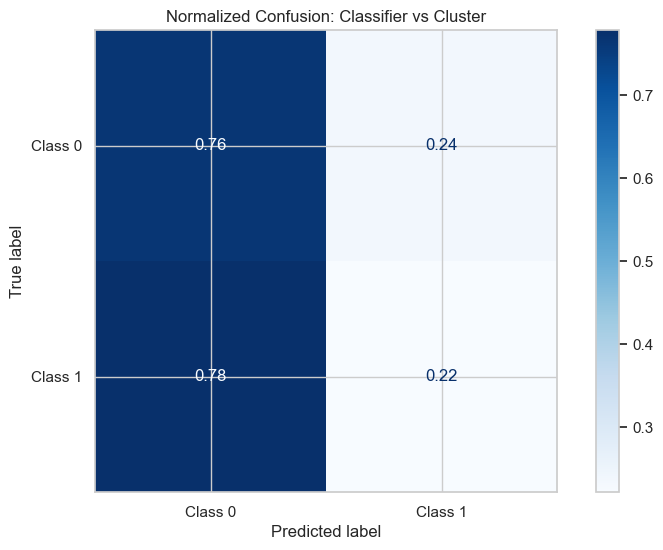

In [12]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues', values_format=".2f")
plt.title("Normalized Confusion: Classifier vs Cluster")
plt.show()
